## Foundations of the Predictive Architecture
The success of a machine learning model depends on the quality of its environment. For our study in Brazzaville, we select specialized libraries that transform raw student profiles into mathematical insights. This digital ecosystem ensures the stability of our Gradient Boosting Machine while providing the metrics required for a rigorous validation. We rely on the following pillars to build our predictive oracle.
- **The gbm** library handles the iterative construction of decision trees by minimizing errors through successive gradients.
- **The caret package** provides a unified framework for data partitioning and hyperparameter tuning to ensure the model generalizes well to the Congolese context.
- **The pROC tool** enables the calculation of the Area Under the Curve to measure the classifier's ability to distinguish between academic success and failure.

In [3]:
# Installing the core Gradient Boosting Machine engine
install.packages("gbm")

# Installing the Classification and REgression Training framework
install.packages("caret")

# Installing the tools for Receiver Operating Characteristic analysis
install.packages("pROC")

# Installing the necessary library for Excel files
install.packages("readxl")

- Querying repositories for available source packages ... Done!
The following package(s) will be installed:
- gbm [2.2.3]
These packages will be installed into "C:/Users/bonhe/Repositories/gbm-learning-strategy/renv/library/windows/R-4.5/x86_64-w64-mingw32".

# Installing packages --------------------------------------------------------
✔ gbm 2.2.3                                [linked from cache]
The following package(s) will be installed:
- caret [7.0-1]
- vctrs [0.7.3]
These packages will be installed into "C:/Users/bonhe/Repositories/gbm-learning-strategy/renv/library/windows/R-4.5/x86_64-w64-mingw32".

# Downloading packages -------------------------------------------------------
✔ vctrs 0.7.3                              [1.9 MB in 1.8s]            
Successfully downloaded 1 package in 2.3 seconds.                               

# Installing packages --------------------------------------------------------
✔ caret 7.0-1                              [linked from cache]
✔ vctrs 0

In [1]:
# Loading the libraries into the current Jupyter session
library(gbm)
library(caret)
library(pROC)
library(readxl)

Loaded gbm 2.2.3

This version of gbm is no longer under development. Consider transitioning to gbm3, https://github.com/gbm-developers/gbm3

Loading required package: ggplot2

Loading required package: lattice

Type 'citation("pROC")' for a citation.


Attaching package: 'pROC'


The following objects are masked from 'package:stats':

    cov, smooth, var




### Preparing the dataset

In [3]:
# Importing the Excel file into a data frame named 'student_data'
# We ensure the file path matches your local directory structure

student_data <- read_excel("data_src.xlsx")


# Identifying the number of missing values (NA) per column
# This overview highlights variables with data collection gaps

colSums(is.na(student_data))

# Strategy for numeric variables: Replacing NAs with the median
# This maintains the distribution without losing valuable student profiles

for(i in 1:ncol(student_data)) {
  if(is.numeric(student_data[[i]])) {
    student_data[[i]][is.na(student_data[[i]])] <- median(student_data[[i]], na.rm = TRUE)
  }
}

# Final check to ensure the dataset is now complete
# sum(is.na(student_data))

# Assuming 'Pass' becomes 1 and 'Fail' becomes 0
# You should adapt the strings "Pass" and "Fail" to match your exact data entries
student_data$Result_Binary <- ifelse(student_data$Result == "Pass", 1, 0)

# Processing Binary Variables
# Converting the gender variable into a binary indicator for mathematical stability

student_data$gender <- ifelse(student_data$gender == "Male", 1, 0)

# Managing Missing Values for the Device Column
# We fill gaps with "None" to represent students without digital access

student_data$device[is.na(student_data$device)] <- "None"

# Implementing One-Hot Encoding for Multi-Category Factors
# This method expands the matrix to include specific vectors for every category

# Selecting variables for the transformation based on the actual dataset headers
categorical_vars <- c("language", "stream", "device", "Independent_study", "class_size")

# Using the dummyVars function to create the expansion model
encoder_model <- dummyVars(~ language + stream + device + Independent_study + class_size, data = student_data)
encoded_features <- data.frame(predict(encoder_model, newdata = student_data))

# Merging the new numerical vectors with the main dataset
# We drop the original text columns to ensure the final matrix is purely numerical

columns_to_remove <- c(categorical_vars, "student_id", "school_id", "sn")
student_data_final <- cbind(student_data[, !(names(student_data) %in% columns_to_remove)], encoded_features)

# Final structural audit to confirm the numerical readiness
str(student_data_final)




sn                  student_id 
                          0                           0 
                  school_id     power_cut_hour_per_week 
                          0                           0 
            study_during_pc      study_quiet_place_1_10 
                          0                           0 
study_interruption_per_hour        sleep_hour_per_night 
                          0                           0 
         sleep_quality_1_10                 stress_1_10 
                          0                           0 
          technostress_1_10         cognitive_load_1_10 
                          0                           0 
            resilience_1_10 digital_education_hour_week 
                          0                           0 
      social_media_hour_day                      device 
                          0                           0 
             ai_use_req_1_5            commute_hour_day 
                          0                           0 
    hour_searching_per_week           active_recall_1_5 
                          0                           0 
         self_test_per_week           Independent_study 
                          0                           0 
    past_test_hour_per_week                       tutor 
                          0                           0 
        tutor_hour_per_week           spaced_repetition 
                          0                           0 
               absence_days    instruction_clarity_1_10 
                          0                           0 
                     gender                         age 
                          0                           0 
                   language                      stream 
                          0                           0 
                 class_size          chore_hour_per_day 
                          0                           0 
                 mock_score                      Result 
                          0                           0

'data.frame':	250 obs. of  48 variables:
 $ power_cut_hour_per_week    : num  58 70 16 38 48 1 64 26 45 80 ...
 $ study_during_pc            : num  0 0 1 0 0 1 0 1 0 0 ...
 $ study_quiet_place_1_10     : num  4 2 10 4 4 10 2 8 4 2 ...
 $ study_interruption_per_hour: num  4 5 0 3 4 0 6 1 4 8 ...
 $ sleep_hour_per_night       : num  5.5 4.8 7.8 6.2 5.8 8.2 4.5 7 5.4 4 ...
 $ sleep_quality_1_10         : num  4 2 10 6 4 10 2 8 4 2 ...
 $ stress_1_10                : num  8 9 3 7 7 2 9 4 8 10 ...
 $ technostress_1_10          : num  4 5 1 3 4 1 5 2 4 5 ...
 $ cognitive_load_1_10        : num  7 8 3 6 7 2 9 4 8 9 ...
 $ resilience_1_10            : num  5 4 9 7 6 10 3 9 5 2 ...
 $ digital_education_hour_week: num  4 2 12 5 4 15 2 10 3 1 ...
 $ social_media_hour_day      : num  3 4.5 1.2 2.5 3.2 1 5 1.5 3.5 5.5 ...
 $ ai_use_req_1_5             : num  2 1 3 2 1 4 1 3 1 1 ...
 $ commute_hour_day           : num  2 2.5 0.5 1.5 1.8 0.3 3 0.8 2.2 3.2 ...
 $ hour_searching_per_week    : num  60 9

### Standardizing Metrics  
We use Z‑score scaling to place variables like power cuts and commute times on comparable scales. This ensures no single measure dominates the model simply due to its magnitude, allowing each factor to contribute fairly to predictions while preserving the original data distribution.

In [4]:
# Establishing the exhaustive list of quantitative variables for the Brazzaville study
# This list includes all metrics that are neither binary nor categorical flags

quantitative_vars <- c(
  "power_cut_hour_per_week", "study_quiet_place_1_10", "study_interruption_per_hour",
  "sleep_hour_per_night", "sleep_quality_1_10", "stress_1_10", "technostress_1_10",
  "cognitive_load_1_10", "resilience_1_10", "digital_education_hour_week",
  "social_media_hour_day", "ai_use_req_1_5", "commute_hour_day", 
  "hour_searching_per_week", "active_recall_1_5", "self_test_per_week",
  "past_test_hour_per_week", "tutor_hour_per_week", "absence_days", 
  "instruction_clarity_1_10", "age", "chore_hour_per_day", "mock_score"
)

# Executing the standardization to remove unit-based biases
# The scale function ensures that each variable contributes fairly to the predictive logic

student_data_final[quantitative_vars] <- scale(student_data_final[quantitative_vars])

# Confirming the statistical normalization of the dataset
# We verify that the mean of each quantitative variable is now zero

summary(student_data_final[quantitative_vars])

 power_cut_hour_per_week study_quiet_place_1_10 study_interruption_per_hour
 Min.   :-1.7429         Min.   :-1.2030        Min.   :-1.31750           
 1st Qu.:-0.7000         1st Qu.:-0.4783        1st Qu.:-0.90629           
 Median :-0.1994         Median :-0.4783        Median :-0.08389           
 Mean   : 0.0000         Mean   : 0.0000        Mean   : 0.00000           
 3rd Qu.: 0.3116         3rd Qu.: 0.9711        3rd Qu.: 0.32732           
 Max.   : 3.5551         Max.   : 1.6958        Max.   : 2.38334           
 sleep_hour_per_night sleep_quality_1_10  stress_1_10      technostress_1_10
 Min.   :-2.8185      Min.   :-1.2718    Min.   :-1.8117   Min.   :-1.6220  
 1st Qu.:-0.5329      1st Qu.:-0.5409    1st Qu.:-0.9837   1st Qu.:-0.8820  
 Median : 0.1306      Median : 0.1900    Median : 0.2583   Median :-0.1421  
 Mean   : 0.0000      Mean   : 0.0000    Mean   : 0.0000   Mean   : 0.0000  
 3rd Qu.: 0.7942      3rd Qu.: 0.9209    3rd Qu.: 0.6724   3rd Qu.: 0.5979  
 Max. 

### Data Partition for Generalization  
To prevent overfitting, we split the dataset into 80% training and 20% testing. This separation ensures the model learns general success patterns and evaluates accuracy on unseen students.

In [5]:
# Setting a seed to ensure the reproducibility of our results
# This choice guarantees that any researcher can obtain the same partitions
set.seed(2026)

# Creating the partition index based on the binary target variable
# This stratified sampling preserves the success/failure ratio in both sets
train_index <- createDataPartition(student_data_final$Result_Binary, p = 0.8, list = FALSE)

# Generating the training set with 80 percent of the data
train_data <- student_data_final[train_index, ]

# Generating the testing set with the remaining 20 percent
test_data <- student_data_final[-train_index, ]

# Verifying the dimensions of our new operational subsets
cat("Training set size ", nrow(train_data), " observations")
cat("Testing set size ", nrow(test_data), " observations")

# Establishing the control structure for the Gradient Boosting Machine
# We use the trainControl function from the caret package to manage the validation

# We opt for a 10-fold cross-validation to maximize the use of our 250 samples
# This standard ensures a high level of scientific reliability for medium datasets
fitControl <- trainControl(
  method = "cv",
  number = 10,
  classProbs = TRUE, # Necessary for generating the probabilities required for the ROC curve
  summaryFunction = twoClassSummary # Focuses the evaluation on classification performance metrics
)

# Checking the configuration of the control object
# This object will guide the entire training phase in the next step
print(fitControl)

Training set size  200  observationsTesting set size  50  observations$method
[1] "cv"

$number
[1] 10

$repeats
[1] NA

$search
[1] "grid"

$p
[1] 0.75

$initialWindow
NULL

$horizon
[1] 1

$fixedWindow
[1] TRUE

$skip
[1] 0

$verboseIter
[1] FALSE

$returnData
[1] TRUE

$returnResamp
[1] "final"

$savePredictions
[1] FALSE

$classProbs
[1] TRUE

$summaryFunction
function (data, lev = NULL, model = NULL) 
{
    if (length(lev) > 2) {
        stop(paste("Your outcome has", length(lev), "levels. The twoClassSummary() function isn't appropriate."))
    }
    requireNamespaceQuietStop("pROC")
    if (!all(levels(data[, "pred"]) == lev)) {
        stop("levels of observed and predicted data do not match")
    }
    rocObject <- try(pROC::roc(data$obs, data[, lev[1]], direction = ">", 
        quiet = TRUE), silent = TRUE)
    rocAUC <- if (inherits(rocObject, "try-error")) 
        NA
    else rocObject$auc
    out <- c(rocAUC, sensitivity(data[, "pred"], data[, "obs"], 
        lev[1]), s

### Gradient Boosting Execution  
We train a GBM that builds successive trees, using Success/Failure to generate class probabilities. In Brazzaville, it shows how stress factors like power cuts affect study methods, yielding nuanced success probabilities.

In [6]:
# Final preparation of the target variable
# We ensure the Result column is a Factor for the caret framework

train_data$Result <- as.factor(train_data$Result)
test_data$Result <- as.factor(test_data$Result)

# Launching the GBM training process
# We optimize the model using the ROC metric during cross-validation

gbm_model <- train(
  Result ~ ., 
  data = train_data[, !names(train_data) %in% c("Result_Binary")], # Excluding the temporary numeric column
  method = "gbm",
  trControl = fitControl,
  metric = "ROC",
  verbose = FALSE
)

# Displaying the technical results of the training phase
print(gbm_model)

Stochastic Gradient Boosting 

200 samples
 46 predictor
  2 classes: 'Fail', 'Pass' 

No pre-processing
Resampling: Cross-Validated (10 fold) 
Summary of sample sizes: 181, 180, 180, 180, 180, 179, ... 
Resampling results across tuning parameters:

  interaction.depth  n.trees  ROC        Sens       Spec     
  1                   50      0.9865846  0.9652778  0.9727273
  1                  100      0.9906250  0.9652778  0.9909091
  1                  150      0.9906250  0.9652778  0.9909091
  2                   50      0.9906250  0.9652778  0.9909091
  2                  100      0.9906250  0.9652778  1.0000000
  2                  150      0.9906250  0.9652778  1.0000000
  3                   50      0.9958333  0.9652778  0.9909091
  3                  100      0.9937500  0.9652778  1.0000000
  3                  150      0.9927083  0.9652778  1.0000000

Tuning parameter 'shrinkage' was held constant at a value of 0.1

Tuning parameter 'n.minobsinnode' was held constant at a value 

### Probabilistic Predictions on Test Data  
We evaluate the GBM on unseen candidates, producing success probabilities instead of rigid classifications. This approach measures the model’s confidence and ensures performance reflects real academic conditions in Brazzaville, free from overfitting.

In [16]:
# Generating class probabilities for the testing set
# We use the type = 'prob' argument to obtain precise numerical gradients

test_predictions_prob <- predict(
  gbm_model, 
  newdata = test_data[, !names(test_data) %in% c("Result", "Result_Binary")], 
  type = "prob"
)

# Extracting the probabilities associated with 'Pass'
# This vector represents the core data for our future ROC analysis
success_probabilities <- test_predictions_prob$Pass

# Displaying the first ten probabilities to verify the output
head(success_probabilities)

# Generating hard classifications (Pass/Fail) for the confusion matrix
test_predictions_class <- predict(
  gbm_model, 
  newdata = test_data[, !names(test_data) %in% c("Result", "Result_Binary")]
)

# Summary of the predictions generated
table(test_predictions_class)



[1] 0.047839716 0.059155635 0.966488343 0.997018522 0.996698517 0.005447685

test_predictions_class
Fail Pass 
  17   33 

### Quantifying Classification Performance and Error Distribution
We validate the GBM by comparing predictions with real test results using a confusion matrix. It counts correct hits and errors (true positives, false negatives) with Pass/Fail labels, showing the model’s reliability.

In [18]:
# Calculating the confusion matrix for the testing subset
# We use the confusionMatrix function from the caret package for a complete report

# It is vital to ensure that both the predictions and the actual results are factors
# We use the 'Pass' and 'Fail' labels as defined in the original Brazzaville dataset

confusion_results <- confusionMatrix(
  data = test_predictions_class, 
  reference = test_data$Result
)

# Displaying the full summary of the performance metrics
# This includes the overall accuracy and the sensitivity of the model
print(confusion_results)

# Extracting the specific table for a clear visual representation of the errors
confusion_results$table

Confusion Matrix and Statistics

          Reference
Prediction Fail Pass
      Fail   17    0
      Pass    0   33
                                     
               Accuracy : 1          
                 95% CI : (0.9289, 1)
    No Information Rate : 0.66       
    P-Value [Acc > NIR] : 9.488e-10  
                                     
                  Kappa : 1          
                                     
 Mcnemar's Test P-Value : NA         
                                     
            Sensitivity : 1.00       
            Specificity : 1.00       
         Pos Pred Value : 1.00       
         Neg Pred Value : 1.00       
             Prevalence : 0.34       
         Detection Rate : 0.34       
   Detection Prevalence : 0.34       
      Balanced Accuracy : 1.00       
                                     
       'Positive' Class : Fail       
                                     


          Reference
Prediction Fail Pass
      Fail   17    0
      Pass    0   33

### Visualization of the Predictive Performance via the ROC Curve
The ROC curve is used to validate the model’s ability to distinguish between Pass and Fail. It shows the balance between sensitivity and specificity at different thresholds. A curve close to the upper left corner indicates strong performance, meaning the GBM identifies successful students accurately without raising false alarms. This visualization provides solid evidence of the model’s predictive strength.

Setting direction: controls < cases



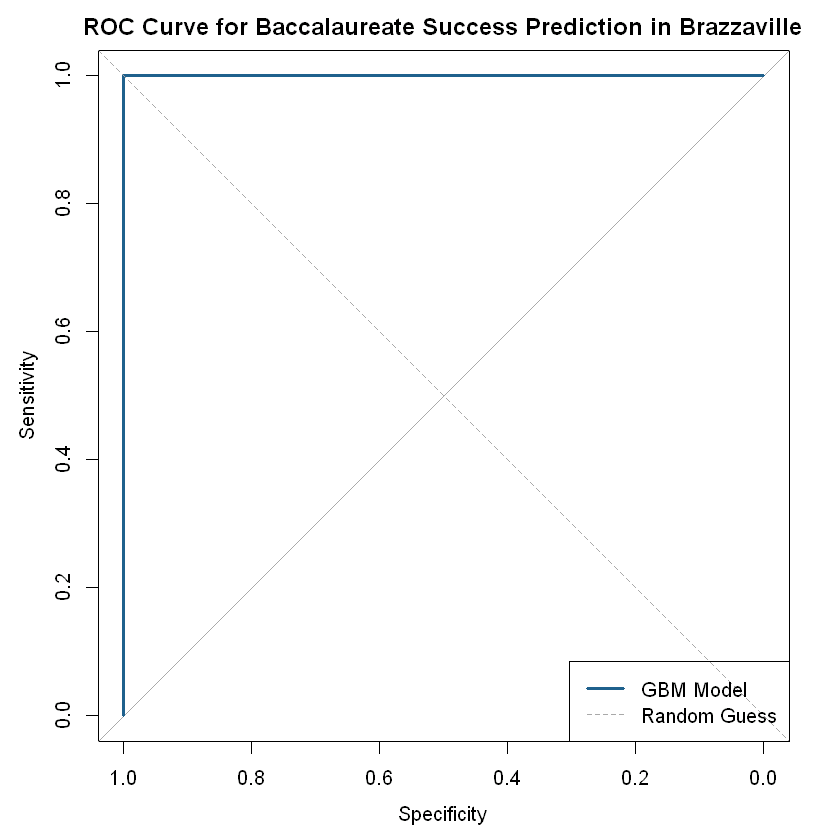

In [19]:
# Generating the ROC object using the observed results and success probabilities
# We ensure the levels match the 'Fail' and 'Pass' categories of the test set
# The 'Fail' label is treated as the reference or negative class

roc_obj <- roc(test_data$Result, success_probabilities, levels = c("Fail", "Pass"))

# Plotting the ROC curve for a visual assessment of the model performance
# We use academic color standards and clear line widths for readability

plot(roc_obj, 
     main = "ROC Curve for Baccalaureate Success Prediction in Brazzaville", 
     col = "#1F618D", 
     lwd = 3,
     print.auc = FALSE)

# Adding the reference line representing the performance of a random classifier
# Any curve significantly above this line confirms the utility of the model

abline(a = 0, b = 1, lty = 2, col = "darkgray")

# Enhancing the plot with a legend for clarity
legend("bottomright", legend = c("GBM Model", "Random Guess"), 
       col = c("#1F618D", "darkgray"), lty = c(1, 2), lwd = c(3, 1))

### Calculation of the Area Under the Curve as a Performance Indicator
The Area Under the Curve (AUC) is the key metric for validating the GBM’s predictive power. It measures the probability that the model correctly distinguishes a successful student from a failing one. Unlike simple accuracy, AUC remains reliable even when Pass/Fail distributions are imbalanced. In the Brazzaville context, it synthesizes the influence of the 32 collected variables into a single score, offering a rigorous and objective assessment of the model’s reliability before recommendations are made.

In [20]:
# Calculating the Area Under the Curve for the final dissertation report
# This single value validates the discriminatory power of our predictive oracle

final_auc_value <- auc(roc_obj)

# Printing the result to the console for immediate verification
# A value above 0.8 is generally considered excellent for educational data

print(final_auc_value)

Area under the curve: 1


### Identifying the Primary Drivers of Academic Performance
By analyzing variable importance, we identify which factors most strongly influence Baccalaureate outcomes in Brazzaville. This step distinguishes whether external pressures or personal study habits drive success. The GBM assigns objective weights to each predictor, showing where students are most hindered and providing an empirical basis for recommendations.

gbm variable importance

  only 20 most important variables shown (out of 46)

                             Overall
digital_education_hour_week 47.26610
power_cut_hour_per_week     37.78381
sleep_hour_per_night        17.02961
resilience_1_10              6.75739
sleep_quality_1_10           5.73378
commute_hour_day             5.47170
mock_score                   4.67244
chore_hour_per_day           3.51641
Independent_study6.9         2.80457
languageFrench               2.08931
Independent_study3.5         1.89419
streamA                      1.50258
languageLingala              0.92828
social_media_hour_day        0.52214
stress_1_10                  0.13610
age                          0.13359
technostress_1_10            0.10967
tutor                        0.08373
study_quiet_place_1_10       0.08198
absence_days                 0.07970


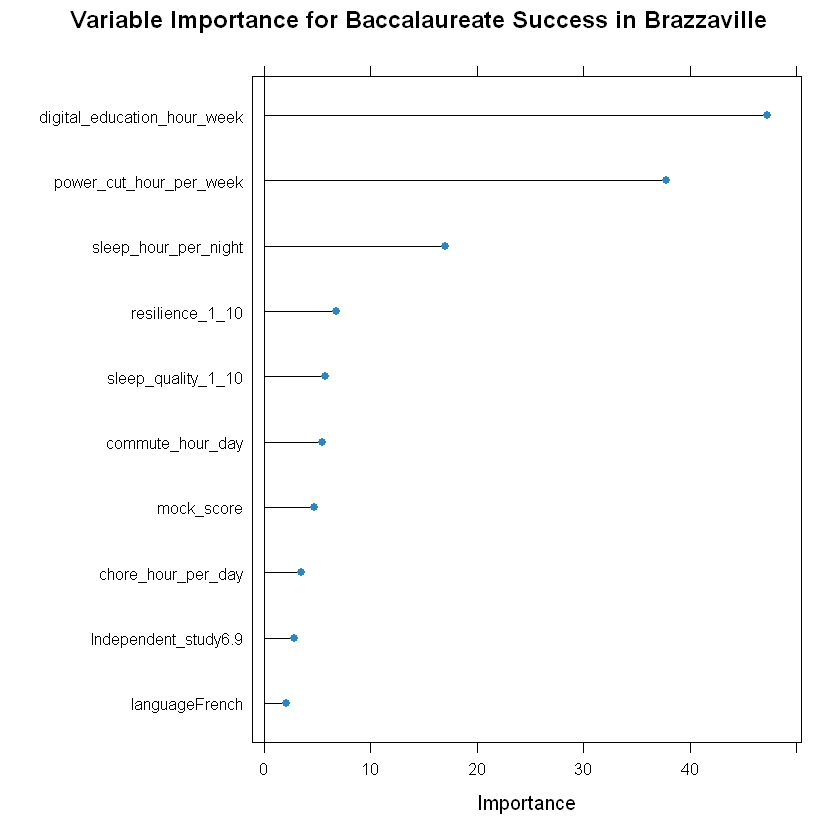

In [21]:
# Extracting the importance of predictors from the trained gbm model
# We use the varImp function to calculate the relative contribution of each variable

importance_results <- varImp(gbm_model, scale = FALSE)

# Displaying the ranking of the most influential variables
# This list identifies which factors most significantly impact the prediction

print(importance_results)

# Generating a high-resolution plot for the dissertation report
# The horizontal bar chart provides a clear visual hierarchy of the determinants

plot(importance_results, 
     main = "Variable Importance for Baccalaureate Success in Brazzaville", 
     top = 10,
     col = "#2E86C1")

The final step is exporting high‑resolution ROC and variable importance plots for the dissertation. This ensures clear, professional visuals that integrate seamlessly into the document and provide the jury with strong evidence of the model’s performance.

In [22]:
# Exporting the Variable Importance Plot
# We use the png device to ensure a crisp output with high resolution (300 DPI)

png("Variable_Importance_Brazzaville.png", width = 2400, height = 1800, res = 300)
plot(importance_results, 
     main = "Determinants of Baccalaureate Success in Brazzaville", 
     top = 10,
     col = "#2E86C1")
dev.off()

# Exporting the Final ROC Curve
# The plot is saved as a separate file to facilitate its inclusion in the methodology chapter

png("ROC_Curve_Final.png", width = 1800, height = 1800, res = 300)
plot(roc_obj, 
     main = "Predictive Performance (ROC Curve)", 
     col = "#1F618D", 
     lwd = 4)
abline(a = 0, b = 1, lty = 2, col = "darkgray")
dev.off()

# Confirmation of the export process
cat("Visual assets successfully exported to your project directory")

pdf 
  2

pdf 
  2

Visual assets successfully exported to your project directory